In [4]:
import pandas as pd
import numpy as np
import umap
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
import igraph as ig
import leidenalg

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("umap-learn:", umap.__version__)
print("igraph:", ig.__version__)
print("leidenalg:", leidenalg.__version__)
print("scikit-learn:", sklearn.__version__)


pandas: 2.3.3
numpy: 2.3.4
umap-learn: 0.5.9.post2
igraph: 0.11.9
leidenalg: 0.10.2
scikit-learn: 1.7.2


In [1]:
import pandas as pd
import numpy as np
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
import igraph as ig
import leidenalg

# ---- 1) Load your CSV ----
input_path = r"D:\OneDrive - UNSW\Projects\RESEARCH - John PIMANDA\Radius 100 - Exponential Dropoff - Self Excluded - Negative Filtered Out.csv"
df = pd.read_csv(input_path)

print("Loaded table:", df.shape)
df.head()

# ---- 2) Choose feature columns ----
feature_cols = ["Neg", "CD8_T", "CD4_T", "Endothelial", "Stromal", "HSPC"]
# feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()   # alternative

X = df[feature_cols].values

# ---- 3) Standardize (z-score) ----
X_scaled = StandardScaler().fit_transform(X)

# ---- 4) Compute UMAP ----
reducer = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
)
embedding = reducer.fit_transform(X_scaled)

df["UMAP_1"] = embedding[:, 0]
df["UMAP_2"] = embedding[:, 1]

C:\Users\Michael Carnell\anaconda3\envs\umap-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded table: (1046942, 10)


C:\Users\Michael Carnell\anaconda3\envs\umap-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [2]:
# ---- 5) Build kNN graph from UMAP embedding ----
# (Leiden operates on a graph of sample-to-sample connections)
n_neighbors = 100
knn_graph = kneighbors_graph(embedding, n_neighbors=n_neighbors, include_self=False)
sources, targets = knn_graph.nonzero()
G = ig.Graph(zip(sources, targets), directed=False)

# ---- 6) Run Leiden clustering ----
partition = leidenalg.find_partition(
    G,
    leidenalg.RBConfigurationVertexPartition,
    resolution_parameter=0.5,
    n_iterations=-1,   # until convergence
    seed=42
)
labels = np.array(partition.membership)

df["Leiden_Group"] = labels
print("Unique Leiden groups:", np.unique(labels))


Unique Leiden groups: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58]


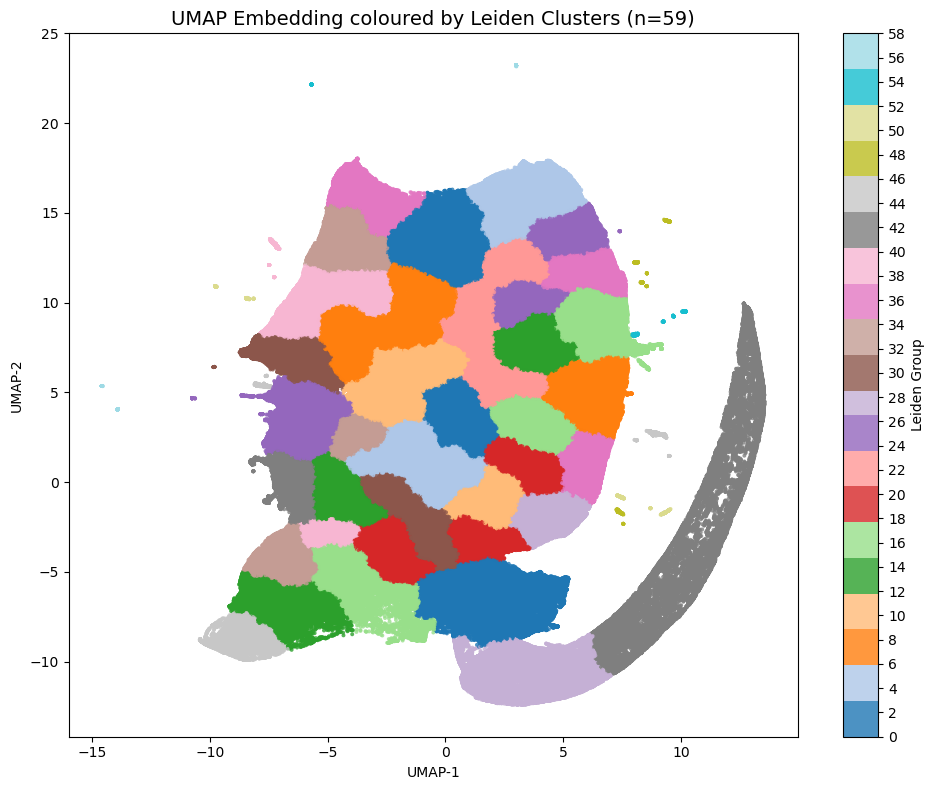

In [3]:
import matplotlib.pyplot as plt

# Assuming you already have:
#  - `embedding`: your UMAP result as an (n_samples x 2) numpy array
#  - `labels`: the Leiden cluster labels (e.g. from partition.membership)
#  - `df`: optional DataFrame containing your data and "Leiden_Group" column

# Optional: choose colormap
cmap = plt.get_cmap('tab20', np.unique(labels).size)

plt.figure(figsize=(10, 8))
sc = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=labels,
    cmap=cmap,
    s=8,
    alpha=0.8,
    linewidths=0
)
plt.title(f"UMAP Embedding coloured by Leiden Clusters (n={len(np.unique(labels))})", fontsize=14)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(sc, ticks=range(0, np.unique(labels).size, max(1, np.unique(labels).size // 20)), label="Leiden Group")
plt.tight_layout()
plt.show()